In [1]:
# conda activate meteor (becasue python 9 is installed here)
# rm -r venv
# make first-venv
# make clean
# make virtual-environment
# source venv/bin/activate
# then select the kernel 'venv' in jupyter notebook

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from dataclasses import asdict
import warnings
from pandas.errors import SettingWithCopyWarning
from functools import partial
#warnings.filterwarnings('ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
#warnings.filterwarnings("ignore", message=".*not in pamset.*")

from meteor import MeteorPatternScaling, meteor_plot_utils
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM
from ciceroscm import input_handler

from meteor.prpatt import global_mean
from meteor.prpatt import recon

import cartopy.crs as ccrs
import cartopy as cart
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
from tqdm import tqdm

In [2]:
cachedir = os.path.join(os.getcwd(), "cache")
if not os.path.exists(cachedir):
        os.makedirs(cachedir)
        
figdir = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figdir):
        os.makedirs(figdir)

cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Data preparations

### Getting some data that can be used by the forcer engine and ciceroscm

SSP245 for aerorol residual from abrupt-4xCO2

In [3]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
conc_data = input_handler.read_inputfile(os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt"))
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

standard SSP scenarios

In [4]:
scenarios = [ "ssp126", "ssp245", "ssp370", "ssp585"]

In [5]:
%%capture
#For predictions: read in SSP concentrations and emissions
#scenarios = ["ssp126","ssp245","ssp370","ssp585"]

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_fwd=[]
em_data_fwd=[]
for i,s in enumerate(scenarios):
    conc_data_fwd.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_fwd.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

SSP534-over

In [6]:
%%capture
#For predictions: read in SSP concentrations and emissions

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_ssp534=[]
em_data_ssp534=[]
for i,s in enumerate(['ssp534-over']):
    conc_data_ssp534.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_ssp534.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

### Getting data for standard scenarios

Getting CMIP6 data from the zarrstore for tas

In [7]:
flds = ["tas","pr"]

In [8]:
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp126", "ssp245", "ssp370", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP','ScenarioMIP', 'ScenarioMIP'])

#for property, value in vars(data_getter).items():
#    print(property)

In [9]:
models = data_getter.models
len(models)

35

Create training data dictionary for all selected models (may run for a while) - and save locally in 'cache' (cachedir) due to data memory requirements

In [10]:
# remove problematic models when creating the pattern
if 'IITM-ESM' in models: models.pop(models.index('IITM-ESM'))  # drop because bad data
if 'IPSL-CM6A-LR' in models: models.pop(models.index('IPSL-CM6A-LR'))  # drop because of data issue
if 'TaiESM1' in models: models.pop(models.index('TaiESM1'))  # drop because of data issue
if 'EC-Earth3' in models: models.pop(models.index('EC-Earth3'))  # drop because of data issue in pr
if 'GISS-E2-1-G' in models: models.pop(models.index('GISS-E2-1-G'))  # drop temperature fit doesn't work
if 'MIROC6' in models: models.pop(models.index('MIROC6'))
if 'MPI-ESM1-2-LR' in models: models.pop(models.index('MPI-ESM1-2-LR'))
if 'FGOALS-g3' in models: models.pop(models.index('FGOALS-g3'))    # data offset between piC and hist
if 'MRI-ESM2-0' in models: models.pop(models.index('MRI-ESM2-0'))
if 'CESM2-WACCM' in models: models.pop(models.index('CESM2-WACCM'))  # no data after 2050 for tas in SSP370

In [11]:
training_data_dict={}
for nm,mname in enumerate(models):
    #print(nm,mname)

    training_data_dict[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),#.isel(year=slice(-200, None)),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")).isel(year=slice(0, 150)),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")).isel(year=slice(0,251)),
        "ssp126": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp126_training_data.nc")).isel(year=slice(0,251)),
        "ssp245": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp245_training_data.nc")).isel(year=slice(0,251)),
        "ssp370": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp370_training_data.nc")).isel(year=slice(0,251)),
        "ssp585": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp585_training_data.nc")).isel(year=slice(0,251)),
    }

### Getting data for SSP534-over

In [12]:
data_getter_ssp534 = Cmip6MeteorDataGetter(exps=["piControl", "historical", "ssp534-over", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP'])

models_ssp534 = data_getter_ssp534.models
len(models_ssp534)

/Users/nste/Documents/entra/projects/d41_METEOR/d41.scripts/METEOR/src/meteor/cmip6_meteor_data_getter.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ScenarioMIP' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_all[i][j].loc[n] = tt.values[0]
/Users/nste/Documents/entra/projects/d41_METEOR/d41.scripts/METEOR/src/meteor/cmip6_meteor_data_getter.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NCAR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_all[i][j].loc[n] = tt.values[0]
/Users/nste/Documents/entra/projects/d41_METEOR/d41.scripts/METEOR/src/meteor/cmip6_meteor_data_getter.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CESM2-WAC

12

In [13]:
if 'UKESM1-0-LL' in models_ssp534: models_ssp534.pop(models_ssp534.index('UKESM1-0-LL'))  # ominous data
if 'EC-Earth3' in models_ssp534: models_ssp534.pop(models_ssp534.index('EC-Earth3'))   # data issue (with pr?)
if 'IPSL-CM6A-LR' in models_ssp534: models_ssp534.pop(models_ssp534.index('IPSL-CM6A-LR'))   # nan data issue
if 'FGOALS-g3' in models_ssp534: models_ssp534.pop(models_ssp534.index('FGOALS-g3'))  # data offset between piC and hist
if 'MIROC6' in models_ssp534: models_ssp534.pop(models_ssp534.index('MIROC6'))
if 'GISS-E2-1-G' in models_ssp534: models_ssp534.pop(models_ssp534.index('GISS-E2-1-G'))

In [14]:
# load locally saved training data
training_data_dict_ssp534={}
for nm,mname in enumerate(models_ssp534):
    #print(nm,mname)

    training_data_dict_ssp534[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")), #.isel(year=slice(-200,None)),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")).isel(year=slice(0, 150)),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")).isel(year=slice(0,251)),
        "ssp534-over": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp534-over_training_data.nc")).isel(year=slice(0,251)),
    }

# Create GHG modes and patterns for all selected models

In [15]:
%%capture

CMIP_pattern_dict = {}
for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    CMIP_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 3, "pr": 3},
            lambda key: training_data_dict[mname][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
            anom_timescales={"tas": 3, "pr": 3}
        )


In [16]:
%%capture
# also capture the spatial response of the last 20 years (2080--2100)

# Define target grid from the reference model
target_model_grid = 'ACCESS-CM2'
target_ds = training_data_dict[target_model_grid]['base']['tas']

# Target latitude and longitude
target_lats = target_ds.lat
target_lons = target_ds.lon

# Loop over variables and scenarios
#patterns_aer_ssp_common_grid = np.zeros([len(scenarios), len(flds), len(models), len(target_lats), len(target_lons)])
patterns_aer_ssp_common_grid_ts = np.zeros([len(scenarios), len(flds), len(models), 351, len(target_lats), len(target_lons)])

for nv, var in enumerate(flds):
    for nsc, sc in enumerate(scenarios):

        # for nm, mname in enumerate(models):
        #     # Get native data as an xarray DataArray
        #     native_ds = CMIP_pattern_dict[mname].predict_from_combined_experiment(
        #         em_data_fwd[nsc], conc_data_fwd[nsc], [var], return_patterns_per_mode=True
        #     )[var].isel(time=slice(-20, None)).mean(dim='time')

        #     # Interpolate to the target grid
        #     regridded_data = native_ds.interp(lat=target_lats, lon=target_lons, method="linear")

        #     # Store in final array
        #     patterns_aer_ssp_common_grid[nsc, nv, nm, :, :] = np.nansum(regridded_data,0)

        ### temporally resolved
        for nm, mname in enumerate(models):
            native_ds = CMIP_pattern_dict[mname].predict_from_combined_experiment(
                em_data_fwd[nsc], conc_data_fwd[nsc], [var], return_patterns_per_mode=True
            )

            native_data = np.sum(native_ds[var].values, axis=0)

            # Convert to xarray DataArray
            native_da = xr.DataArray(native_data, dims=["time", "lat", "lon"],
                                 coords={"time": np.arange(0,351),
                                         "lat": native_ds[var].lat,
                                         "lon": native_ds[var].lon})

            # Interpolate to the target grid
            regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")

            # Store in final array
            patterns_aer_ssp_common_grid_ts[nsc, nv, nm, :, :, :] = regridded_data

##del(model_data_list)
del(CMIP_pattern_dict)

extract target model grid for later

In [17]:
# Define target grid from the reference model
target_model_grid = 'ACCESS-CM2'
target_ds = training_data_dict[target_model_grid]['base']['tas']


common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

interpolate temporally resolved training data - standard SSPs

In [18]:
# interpolate gridded data to common grid


# Note: some models have less than 251 values, so need to use the smalles possible common period
td_ssp_common_grid_ts = np.zeros([len(flds),len(scenarios),len(models),249,len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
            native_data = training_data_dict[mname][sc][var].values[0,0:249,:,:]
            native_lons = training_data_dict[mname][sc][var].lon
            native_lats = training_data_dict[mname][sc][var].lat
            #native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            native_da = xr.DataArray(
                native_data,
                dims=["time", "lat", "lon"],
                coords={"time": np.arange(0,249), "lat": native_lats, "lon": native_lons}
            )

            regridded_da = native_da.interp(lat=common_lats, lon=common_lons, method="linear")

            # Interpolate
            #td_ssp534_common_grid[nv,nsc,nm,:,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
            #                                np.array(native_data).flatten(), 
            #                                (common_lon_grid, common_lat_grid), method='cubic')
            td_ssp_common_grid_ts[nv, nsc, nm, :, :, :] = regridded_da.values

In [19]:
del(training_data_dict)

# Application to new scenarios

### SSP534-over

In [20]:
%%capture

# # Define target grid from the reference model
# target_model_grid = 'ACCESS-CM2'
# target_ds = training_data_dict[target_model_grid]['base']['tas']

# Target latitudes and longitudes
target_lats = target_ds.lat
target_lons = target_ds.lon

# Preallocate final mean array
#patterns_ssp534_common_grid = np.zeros([1, len(flds), len(models), len(target_lats), len(target_lons)])
patterns_ssp534_common_grid_ts = np.zeros([1, len(flds), len(models_ssp534), 351, len(target_lats), len(target_lons)])


# Store predictions
patterns_ssp534 = {}

for nm, mname in enumerate(models_ssp534):
    patterns_ssp534[mname] = {}

    # Create pattern scaling object
    CMIP_pattern_ssp534 = MeteorPatternScaling(
        mname,
        {"tas": 3, "pr": 3},
        lambda key: training_data_dict_ssp534[mname][key],
        from_file=False,
        exp_list=["base", "co2x4", "sulxanom"],
        anom_timescales={"tas": 3, "pr": 3}
    )

    # Process SSP534-over scenario
    sc = "ssp534-over"
    patterns_ssp534[mname][sc] = CMIP_pattern_ssp534.predict_from_combined_experiment(
        em_data_ssp534[0], conc_data_ssp534[0], ["pr", "tas"], return_patterns_per_mode=True
    )

# Interpolation and Model Mean Calculation
for nv, var in enumerate(flds):

    for nm, mname in enumerate(models_ssp534):
        # # Extract native data and compute mean over last 20 years
        # native_data = np.nanmean(
        #     np.sum(patterns_ssp534[mname][sc][var].values[:, -20:, :, :], axis=0), axis=0
        # )

        # # Convert to xarray DataArray
        # native_da = xr.DataArray(native_data, dims=["lat", "lon"],
        #                          coords={"lat": patterns_ssp534[mname][sc][var].lat,
        #                                  "lon": patterns_ssp534[mname][sc][var].lon})

        # # Interpolate to common grid
        # regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")

        # # Store in final array
        # patterns_ssp534_common_grid[0, nv, nm, :, :] = regridded_data.values


        ### temporally resolved
        native_data = np.sum(patterns_ssp534[mname][sc][var].values[:, :, :, :], axis=0)

        # Convert to xarray DataArray
        native_da = xr.DataArray(native_data, dims=["time", "lat", "lon"],
                                 coords={"time": np.arange(0,351),
                                         "lat": patterns_ssp534[mname][sc][var].lat,
                                         "lon": patterns_ssp534[mname][sc][var].lon})

        # Interpolate to common grid
        regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")

        # Store in final array
        patterns_ssp534_common_grid_ts[0, nv, nm, :, :, :] = regridded_data.values

#del(model_data_list)
del(CMIP_pattern_ssp534)

interpolate temporally resolved training data - SSP534

In [21]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

# target_model_grid = 'ACCESS-CM2'

# common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
# common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
# common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

td_ssp534_common_grid_ts = np.zeros([len(flds),1,len(models_ssp534),251,len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            native_data = training_data_dict_ssp534[mname][sc][var].values[0,:,:,:]
            native_lons = training_data_dict_ssp534[mname][sc][var].lon
            native_lats = training_data_dict_ssp534[mname][sc][var].lat
            #native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            native_da = xr.DataArray(
                native_data,
                dims=["time", "lat", "lon"],
                coords={"time": np.arange(0,251), "lat": native_lats, "lon": native_lons}
            )

            regridded_da = native_da.interp(lat=common_lats, lon=common_lons, method="linear")

            # Interpolate
            #td_ssp534_common_grid[nv,nsc,nm,:,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
            #                                np.array(native_data).flatten(), 
            #                                (common_lon_grid, common_lat_grid), method='cubic')
            td_ssp534_common_grid_ts[nv, nsc, nm, :, :, :] = regridded_da.values

In [22]:
del(training_data_dict_ssp534)

# Plotting

Define regions

In [23]:
EUR_bnds = {"lon_min": 0, "lon_max": 45, "lat_min": 37, "lat_max": 75}    # EU
HAR_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": 70, "lat_max": 90}    # High Arctic
HAN_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": -90, "lat_max": -55}    # High Antarctic
EQU_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": -20, "lat_max": 20} 
SAM_bnds = {"lon_min": 275, "lon_max": 330, "lat_min": -60, "lat_max": 15}  # SAm
NAM_bnds = {"lon_min": 200, "lon_max": 310, "lat_min": 10, "lat_max": 70}  # NAm
SEA_bnds = {"lon_min": 95, "lon_max": 165, "lat_min": -45, "lat_max": 5}  # SEA
EAS_bnds = {"lon_min": 65, "lon_max": 150, "lat_min": 5, "lat_max": 60}   # EAs
AFR_bnds = {"lon_min": 0, "lon_max": 60, "lat_min": -40, "lat_max": 37}   # AF

lon_orig_idx_EU = np.where((common_lons >= EUR_bnds["lon_min"]) & (common_lons <= EUR_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= EUR_bnds["lat_min"]) & (common_lats <= EUR_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= HAR_bnds["lon_min"]) & (common_lons <= HAR_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= HAR_bnds["lat_min"]) & (common_lats <= HAR_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= HAN_bnds["lon_min"]) & (common_lons <= HAN_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= HAN_bnds["lat_min"]) & (common_lats <= HAN_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= EQU_bnds["lon_min"]) & (common_lons <= EQU_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= EQU_bnds["lat_min"]) & (common_lats <= EQU_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= SAM_bnds["lon_min"]) & (common_lons <= SAM_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= SAM_bnds["lat_min"]) & (common_lats <= SAM_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= NAM_bnds["lon_min"]) & (common_lons <= NAM_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= NAM_bnds["lat_min"]) & (common_lats <= NAM_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= SEA_bnds["lon_min"]) & (common_lons <= SEA_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= SEA_bnds["lat_min"]) & (common_lats <= SEA_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= EAS_bnds["lon_min"]) & (common_lons <= EAS_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= EAS_bnds["lat_min"]) & (common_lats <= EAS_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= AFR_bnds["lon_min"]) & (common_lons <= AFR_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= AFR_bnds["lat_min"]) & (common_lats <= AFR_bnds["lat_max"]))[0]

In [24]:
EUR_bnds = {"lon_min": 0, "lon_max": 45, "lat_min": 37, "lat_max": 75}    # EU
HAR_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": 70, "lat_max": 90}    # High Arctic
HAN_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": -90, "lat_max": -55}    # High Antarctic
EQU_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": -20, "lat_max": 20} 
SAM_bnds = {"lon_min": 275, "lon_max": 330, "lat_min": -60, "lat_max": 15}  # SAm
NAM_bnds = {"lon_min": 200, "lon_max": 310, "lat_min": 10, "lat_max": 70}  # NAm
SEA_bnds = {"lon_min": 95, "lon_max": 165, "lat_min": -45, "lat_max": 5}  # SEA
EAS_bnds = {"lon_min": 65, "lon_max": 150, "lat_min": 5, "lat_max": 60}   # EAs
AFR_bnds = {"lon_min": 0, "lon_max": 60, "lat_min": -40, "lat_max": 37}   # AF

lon_orig_idx = {}
lon_orig_idx["EUR"] = np.where((common_lons >= EUR_bnds["lon_min"]) & (common_lons <= EUR_bnds["lon_max"]))[0]
lon_orig_idx["HAR"] = np.where((common_lons >= HAR_bnds["lon_min"]) & (common_lons <= HAR_bnds["lon_max"]))[0]
lon_orig_idx["HAN"] = np.where((common_lons >= HAN_bnds["lon_min"]) & (common_lons <= HAN_bnds["lon_max"]))[0]
lon_orig_idx["EQU"] = np.where((common_lons >= EQU_bnds["lon_min"]) & (common_lons <= EQU_bnds["lon_max"]))[0]
lon_orig_idx["SAM"] = np.where((common_lons >= SAM_bnds["lon_min"]) & (common_lons <= SAM_bnds["lon_max"]))[0]
lon_orig_idx["NAM"] = np.where((common_lons >= NAM_bnds["lon_min"]) & (common_lons <= NAM_bnds["lon_max"]))[0]
lon_orig_idx["SEA"] = np.where((common_lons >= SEA_bnds["lon_min"]) & (common_lons <= SEA_bnds["lon_max"]))[0]
lon_orig_idx["EAS"] = np.where((common_lons >= EAS_bnds["lon_min"]) & (common_lons <= EAS_bnds["lon_max"]))[0]
lon_orig_idx["AFR"] = np.where((common_lons >= AFR_bnds["lon_min"]) & (common_lons <= AFR_bnds["lon_max"]))[0]

lat_orig_idx = {}
lat_orig_idx["EUR"] = np.where((common_lats >= EUR_bnds["lat_min"]) & (common_lats <= EUR_bnds["lat_max"]))[0]
lat_orig_idx["HAR"] = np.where((common_lats >= HAR_bnds["lat_min"]) & (common_lats <= HAR_bnds["lat_max"]))[0]
lat_orig_idx["HAN"] = np.where((common_lats >= HAN_bnds["lat_min"]) & (common_lats <= HAN_bnds["lat_max"]))[0]
lat_orig_idx["EQU"] = np.where((common_lats >= EQU_bnds["lat_min"]) & (common_lats <= EQU_bnds["lat_max"]))[0]
lat_orig_idx["SAM"] = np.where((common_lats >= SAM_bnds["lat_min"]) & (common_lats <= SAM_bnds["lat_max"]))[0]
lat_orig_idx["NAM"] = np.where((common_lats >= NAM_bnds["lat_min"]) & (common_lats <= NAM_bnds["lat_max"]))[0]
lat_orig_idx["SEA"] = np.where((common_lats >= SEA_bnds["lat_min"]) & (common_lats <= SEA_bnds["lat_max"]))[0]
lat_orig_idx["EAS"] = np.where((common_lats >= EAS_bnds["lat_min"]) & (common_lats <= EAS_bnds["lat_max"]))[0]
lat_orig_idx["AFR"] = np.where((common_lats >= AFR_bnds["lat_min"]) & (common_lats <= AFR_bnds["lat_max"]))[0]

regions = ["EUR","HAR","HAN","EQU","SAM","NAM","SEA","EAS","AFR"]

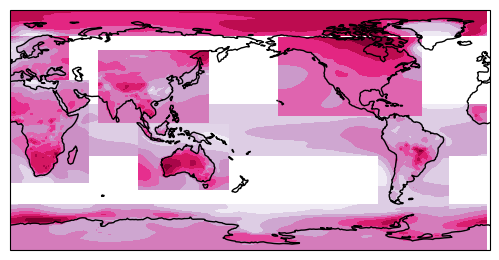

In [25]:
# Plot the regional topography map
fig = plt.figure(figsize=(15, 12.5), layout='tight')

ax = fig.add_subplot(3, 3, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([0,360,-90,90], crs=ccrs.PlateCarree())
ax.coastlines()
for nr,reg in enumerate(regions):
    cont = ax.contourf(common_lons[lon_orig_idx[reg]], common_lats[lat_orig_idx[reg]], patterns_ssp534_common_grid_ts[0,0,0,-1,np.min(lat_orig_idx[reg]):np.max(lat_orig_idx[reg])+1,np.min(lon_orig_idx[reg]):np.max(lon_orig_idx[reg])+1], cmap="PuRd", transform=ccrs.PlateCarree())

Calculate regional means (and realign axes of CMIP and METEOR data, as var and scenario were switched before)

standard SSPs

In [26]:
%%capture
td_ssp_common_grid_ts_reg = np.zeros([len(flds),len(scenarios),len(models),9,249]) * np.nan

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
            for nr,reg in enumerate(regions):
                region_lats = common_lats[lat_orig_idx[reg]]
                weights = np.cos(np.deg2rad(region_lats))     # Compute weights (cosine of latitude in radians)
                weights = weights / weights.sum()             # Normalize weights

                region_data =  td_ssp_common_grid_ts[nv, nsc, nm,:,np.min(lat_orig_idx[reg]):np.max(lat_orig_idx[reg])+1,np.min(lon_orig_idx[reg]):np.max(lon_orig_idx[reg])+1] # [time, lat, lon]
                region_mean_lon = np.nanmean(region_data, axis=2)   # First, average over longitude (axis=2)
                region_masked = np.ma.masked_invalid(region_mean_lon)    # filter any nans
                td_ssp_common_grid_ts_reg[nv, nsc, nm, nr, :] = np.ma.average(region_masked, axis=1, weights=weights).filled(np.nan)     # Then, weighted average over latitude (axis=1)

In [29]:
%%capture
patterns_ssp_common_grid_ts_reg = np.zeros([len(flds),len(scenarios),len(models),9,351]) * np.nan

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
            for nr,reg in enumerate(regions):
                region_lats = common_lats[lat_orig_idx[reg]]
                weights = np.cos(np.deg2rad(region_lats))     # Compute weights (cosine of latitude in radians)
                weights = weights / weights.sum()             # Normalize weights

                region_data =  patterns_aer_ssp_common_grid_ts[nsc, nv, nm,:,np.min(lat_orig_idx[reg]):np.max(lat_orig_idx[reg])+1,np.min(lon_orig_idx[reg]):np.max(lon_orig_idx[reg])+1] # [time, lat, lon]
                region_mean_lon = np.nanmean(region_data, axis=2)   # First, average over longitude (axis=2)
                region_masked = np.ma.masked_invalid(region_mean_lon)    # filter any nans
                patterns_ssp_common_grid_ts_reg[nv, nsc, nm, nr, :] = np.ma.average(region_masked, axis=1, weights=weights).filled(np.nan)     # Then, weighted average over latitude (axis=1)

SSP534

In [30]:
%%capture
td_ssp534_common_grid_ts_reg = np.zeros([len(flds),1,len(models_ssp534),9,251]) * np.nan

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            for nr,reg in enumerate(regions):
                region_lats = common_lats[lat_orig_idx[reg]]
                weights = np.cos(np.deg2rad(region_lats))     # Compute weights (cosine of latitude in radians)
                weights = weights / weights.sum()             # Normalize weights

                region_data =  td_ssp534_common_grid_ts[nv, nsc, nm,:,np.min(lat_orig_idx[reg]):np.max(lat_orig_idx[reg])+1,np.min(lon_orig_idx[reg]):np.max(lon_orig_idx[reg])+1] # [time, lat, lon]
                region_mean_lon = np.nanmean(region_data, axis=2)   # First, average over longitude (axis=2)
                region_masked = np.ma.masked_invalid(region_mean_lon)    # filter any nans
                td_ssp534_common_grid_ts_reg[nv, nsc, nm, nr, :] = np.ma.average(region_masked, axis=1, weights=weights).filled(np.nan)     # Then, weighted average over latitude (axis=1)

In [31]:
%%capture
patterns_ssp534_common_grid_ts_reg = np.zeros([len(flds),1,len(models_ssp534),9,351]) * np.nan

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            for nr,reg in enumerate(regions):
                region_lats = common_lats[lat_orig_idx[reg]]
                weights = np.cos(np.deg2rad(region_lats))     # Compute weights (cosine of latitude in radians)
                weights = weights / weights.sum()             # Normalize weights

                region_data =  patterns_ssp534_common_grid_ts[nsc, nv, nm,:,np.min(lat_orig_idx[reg]):np.max(lat_orig_idx[reg])+1,np.min(lon_orig_idx[reg]):np.max(lon_orig_idx[reg])+1] # [time, lat, lon]
                region_mean_lon = np.nanmean(region_data, axis=2)   # First, average over longitude (axis=2)
                region_masked = np.ma.masked_invalid(region_mean_lon)    # filter any nans
                patterns_ssp534_common_grid_ts_reg[nv, nsc, nm, nr, :] = np.ma.average(region_masked, axis=1, weights=weights).filled(np.nan)     # Then, weighted average over latitude (axis=1)

### Combine all scenarios

#

In [35]:
from scipy.stats import linregress

In [33]:
reg_text = ["Europe", "High Arctic", "High Antarctic", "Tropics", "South America", "North America", "East Asia", "Australia", "Africa"]

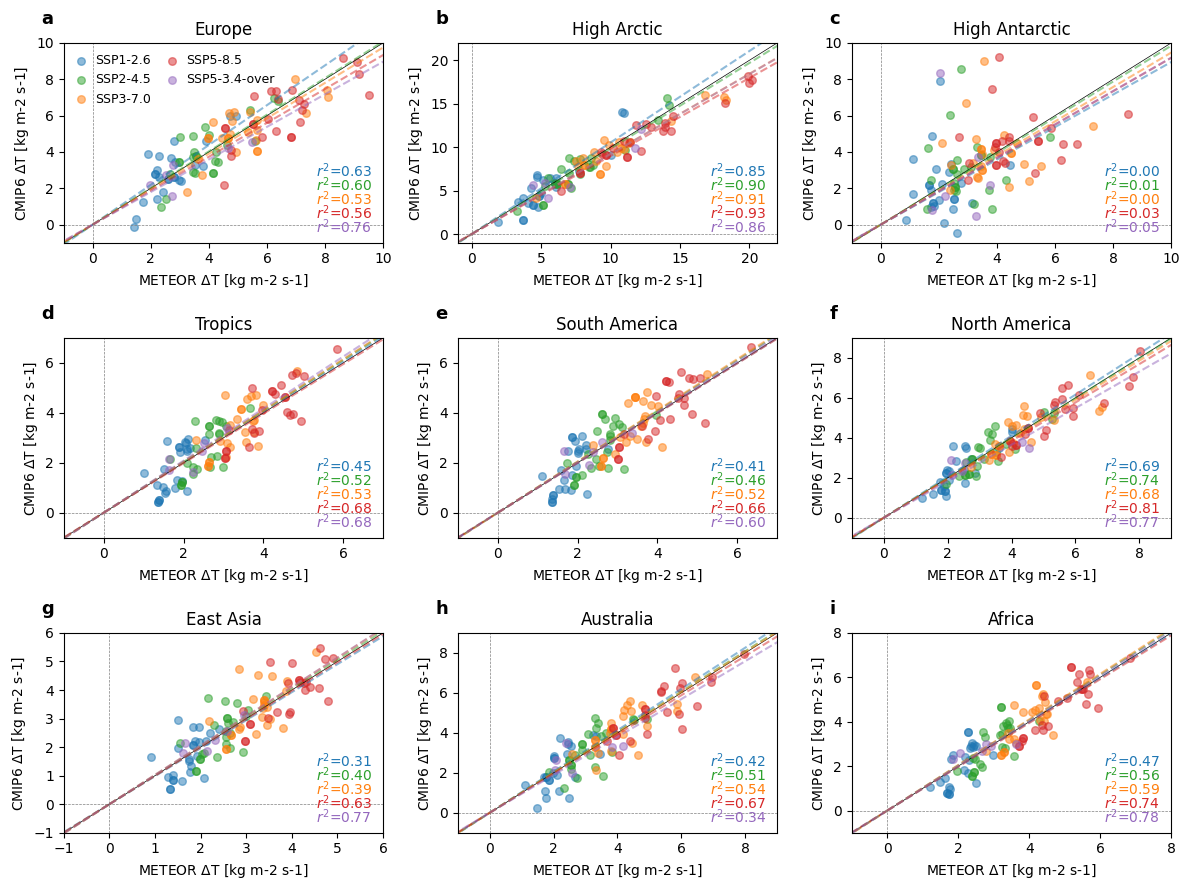

In [186]:
varidx = 0
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
label_loc = [0.36, 0.29, 0.22, 0.15]
sc_labels = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
axlim_min = np.repeat(-1,9)
axlim_max = [10, 22, 10, 7, 7, 9, 6, 9, 8]
panel_labels = ["a","b","c","d","e","f","g","h","i"]

fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout="tight")
axes = axes.flatten()

for nr, reg in enumerate(regions):
    ax = axes[nr]
    ax.set_title(reg_text[nr])
    ax.set_ylabel("CMIP6 $\Delta$T [kg m-2 s-1]")
    ax.set_xlabel("METEOR $\Delta$T [kg m-2 s-1]")
    ax.set_xlim(axlim_min[nr],axlim_max[nr])
    ax.set_ylim(axlim_min[nr],axlim_max[nr])
    ax.plot([-100,100],[-100,100], color="black", lw=0.5)
    ax.axhline(0, color="gray", lw=0.5, linestyle="--")
    ax.axvline(0, color="gray", lw=0.5, linestyle="--")

    # standard SSPs
    for nsc, sc in enumerate(scenarios):
        meteor = np.nanmean(patterns_ssp_common_grid_ts_reg[varidx,nsc,:,nr,-20:],1)
        cmip = np.nanmean(td_ssp_common_grid_ts_reg[varidx,nsc,:,nr,-18:]-np.nanmean(td_ssp_common_grid_ts_reg[varidx,nsc,:,nr,0:50]),1)
        ax.scatter(meteor,cmip, color=colors[nsc], s=30, alpha=0.5, label=sc_labels[nsc])
            
        # Calculate r2 with intercept at 0
        slope, _, _, _ = np.linalg.lstsq(meteor[:, np.newaxis], cmip, rcond=None)
        y_pred = slope * meteor
        #ss_res_diag = np.sum((cmip - meteor) ** 2)
        #ss_tot_diag = np.sum((cmip - np.mean(cmip)) ** 2)
        #r2_diag = 1 - ss_res_diag / ss_tot_diag if ss_tot_diag != 0 else np.nan
        r2 = linregress(meteor, cmip).rvalue ** 2
        ax.annotate(f"$r^2$={r2:.2f}", xy=(0.79, label_loc[nsc]), xycoords='axes fraction', ha='left', va='center', color=colors[nsc])
        ax.plot(slope*np.arange(0,100), color=colors[nsc], alpha=0.5, linestyle="--")
        ax.plot(np.arange(-100,1),slope*np.arange(-100,1), color=colors[nsc], alpha=0.5, linestyle="--")

    # SSP534
    for nsc, sc in enumerate(['ssp534-over']):
        meteor = np.nanmean(patterns_ssp534_common_grid_ts_reg[varidx,nsc,:,nr,-20:],1)
        cmip = np.nanmean(td_ssp534_common_grid_ts_reg[varidx,nsc,:,nr,-18:]-np.nanmean(td_ssp534_common_grid_ts_reg[varidx,nsc,:,nr,0:50]),1)
        ax.scatter(meteor,cmip, color="tab:purple", s=30, alpha=0.5, label="SSP5-3.4-over")

        # Calculate r2 with intercept at 0
        slope, _, _, _ = np.linalg.lstsq(meteor[:, np.newaxis], cmip, rcond=None)
        y_pred = slope * meteor
        #ss_res_diag = np.sum((cmip - meteor) ** 2)
        #ss_tot_diag = np.sum((cmip - np.mean(cmip)) ** 2)
        #r2_diag = 1 - ss_res_diag / ss_tot_diag if ss_tot_diag != 0 else np.nan
        r2 = linregress(meteor, cmip).rvalue ** 2
        ax.annotate(f"$r^2$={r2:.2f}", xy=(0.79, 0.08), xycoords='axes fraction', ha='left', va='center', color="tab:purple")
        ax.plot(slope*np.arange(0,100), color="tab:purple", alpha=0.5, linestyle="--")
        ax.plot(np.arange(-100,1),slope*np.arange(-100,1), color="tab:purple", alpha=0.5, linestyle="--")

    if nr == 0:
        ax.legend(frameon=False, loc="upper left", prop={'size': 9}, ncol=2, columnspacing=0.7, handletextpad=0.1, bbox_to_anchor=[-0.02,1])
    ax.annotate(panel_labels[nr], xy=(-0.07, 1.12), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

plt.savefig(os.path.join(figdir, "CMIP_recon_allSSP_reg_scatter_tas.pdf"), bbox_inches='tight')

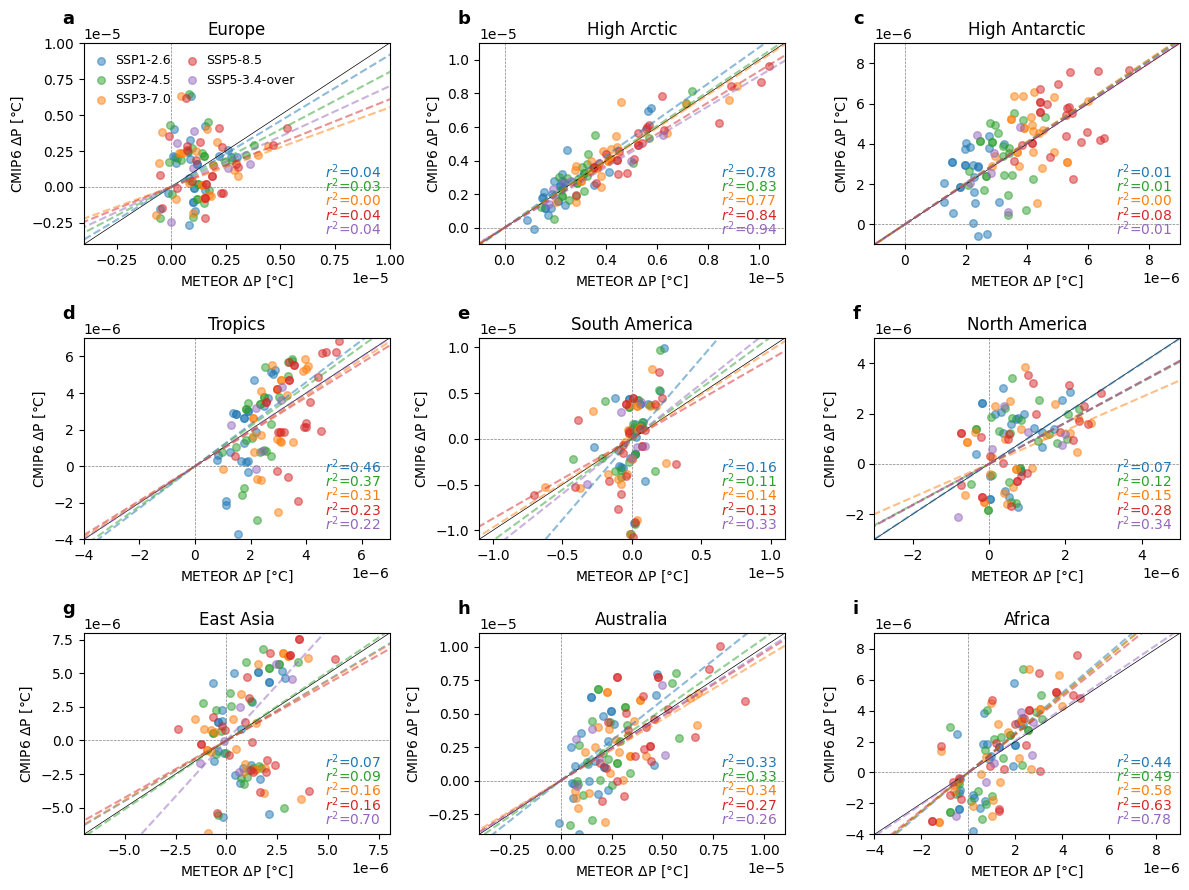

In [187]:
varidx = 1
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
label_loc = [0.36, 0.29, 0.22, 0.15]
sc_labels = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
axlim_min = [-4e-6, -1e-6, -1e-6, -4e-6, -11e-6, -3e-6, -7e-6, -4e-6, -4e-6]
axlim_max = [10e-6, 11e-6, 9e-6, 7e-6, 11e-6, 5e-6, 8e-6, 11e-6, 9e-6]
panel_labels = ["a","b","c","d","e","f","g","h","i"]

fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout="tight")
axes = axes.flatten()

for nr, reg in enumerate(regions):
    ax = axes[nr]
    ax.set_title(reg_text[nr])
    ax.set_ylabel("CMIP6 $\Delta$P [°C]")
    ax.set_xlabel("METEOR $\Delta$P [°C]")
    ax.set_xlim(axlim_min[nr],axlim_max[nr])
    ax.set_ylim(axlim_min[nr],axlim_max[nr])
    ax.plot([-100,100],[-100,100], color="black", lw=0.5)
    ax.axhline(0, color="gray", lw=0.5, linestyle="--")
    ax.axvline(0, color="gray", lw=0.5, linestyle="--")

    # standard SSPs
    for nsc, sc in enumerate(scenarios):
        meteor = np.nanmean(patterns_ssp_common_grid_ts_reg[varidx,nsc,:,nr,-20:],1)
        cmip = np.nanmean(td_ssp_common_grid_ts_reg[varidx,nsc,:,nr,-18:]-np.nanmean(td_ssp_common_grid_ts_reg[varidx,nsc,:,nr,0:50]),1)
        ax.scatter(meteor,cmip, color=colors[nsc], s=30, alpha=0.5, label=sc_labels[nsc])
            
        # Calculate r2 with intercept at 0
        slope, _, _, _ = np.linalg.lstsq(meteor[:, np.newaxis], cmip, rcond=None)
        y_pred = slope * meteor
        #ss_res_diag = np.sum((cmip - meteor) ** 2)
        #ss_tot_diag = np.sum((cmip - np.mean(cmip)) ** 2)
        #r2_diag = 1 - ss_res_diag / ss_tot_diag if ss_tot_diag != 0 else np.nan
        r2 = linregress(meteor, cmip).rvalue ** 2
        ax.annotate(f"$r^2$={r2:.2f}", xy=(0.79, label_loc[nsc]), xycoords='axes fraction', ha='left', va='center', color=colors[nsc])
        ax.plot(slope*np.arange(0,100), color=colors[nsc], alpha=0.5, linestyle="--")
        ax.plot(np.arange(-100,1),slope*np.arange(-100,1), color=colors[nsc], alpha=0.5, linestyle="--")

    # SSP534
    for nsc, sc in enumerate(['ssp534-over']):
        meteor = np.nanmean(patterns_ssp534_common_grid_ts_reg[varidx,nsc,:,nr,-20:],1)
        cmip = np.nanmean(td_ssp534_common_grid_ts_reg[varidx,nsc,:,nr,-18:]-np.nanmean(td_ssp534_common_grid_ts_reg[varidx,nsc,:,nr,0:50]),1)
        ax.scatter(meteor,cmip, color="tab:purple", s=30, alpha=0.5, label="SSP5-3.4-over")

        # Calculate r2 with intercept at 0
        slope, _, _, _ = np.linalg.lstsq(meteor[:, np.newaxis], cmip, rcond=None)
        y_pred = slope * meteor
        #ss_res_diag = np.sum((cmip - meteor) ** 2)
        #ss_tot_diag = np.sum((cmip - np.mean(cmip)) ** 2)
        #r2_diag = 1 - ss_res_diag / ss_tot_diag if ss_tot_diag != 0 else np.nan
        r2 = linregress(meteor, cmip).rvalue ** 2
        ax.annotate(f"$r^2$={r2:.2f}", xy=(0.79, 0.08), xycoords='axes fraction', ha='left', va='center', color="tab:purple")
        ax.plot(slope*np.arange(0,100), color="tab:purple", alpha=0.5, linestyle="--")
        ax.plot(np.arange(-100,1),slope*np.arange(-100,1), color="tab:purple", alpha=0.5, linestyle="--")

    if nr == 0:
        ax.legend(frameon=False, loc="upper left", prop={'size': 9}, ncol=2, columnspacing=0.7, handletextpad=0.1, bbox_to_anchor=[-0.02,1])
    ax.annotate(panel_labels[nr], xy=(-0.07, 1.12), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

plt.savefig(os.path.join(figdir, "CMIP_recon_allSSP_reg_scatter_pr.pdf"), bbox_inches='tight')